# 02 - Predict-then-optimise on the simulated panel

Synthetic counterpart of the empirical quarterly-PD PTO notebook, reading
`data/simulated_pd_panel.csv` produced by `01_simulate_pd_panel_v2`. Structure, models,
and conventions mirror the empirical notebook; the differences exploit what only the
simulation provides.

Shared with the empirical pipeline:

- timing: features dated t (macro observables, `c`, `c_lag1`) predict quarter t+1;
- training target: realised next-quarter implied PD `c_{t+1} / LGD` (noisy but unbiased
  for true PD under the Vasicek sampler); switch `TRAIN_TARGET = "true"` for the
  oracle-target ablation (upper bound on what better prediction could buy);
- models: linear and MLP seed ensemble with logit-space targets, plus a persistence
  baseline `pd_q_hat = c_t / LGD` through the identical decision pipeline;
- expanding-window evaluation, per-window scaler refit, Diebold-Mariano comparisons.

Only possible in simulation:

- prediction accuracy is scored against BOTH realised implied PD and true PD;
- realised utility is evaluated at the true capital requirement `K_IRB_true_{t+1}`
  (matching the simulator's oracle convention);
- two oracles: the perfect-foresight oracle (knows the realised draw; recomputed here and
  cross-checked against the panel) and the Bayes oracle (from the panel; best allocation
  achievable by a perfectly specified model);
- per-model regret decomposition: `regret_foresight = regret_vs_bayes + irreducible`,
  where the irreducible part is the foresight-minus-Bayes gap that no model can close;
- a median-bias correction on the trained models' predictions and an expected-utility
  decision stage (see the dedicated section below); the certainty-equivalent decision is
  recorded alongside as an ablation (`alpha_hat_ce`, `regret_ce`).

In [1]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path
from minou_colors import MINOU_COLORS

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.special import owens_t
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "simulated_pd_panel.csv").exists():
    ROOT = ROOT.parent

PANEL_CSV = ROOT / "data" / "simulated_pd_panel.csv"
METADATA_PATH = ROOT / "data" / "simulated_pd_panel_metadata.json"
FIGURES_DIR = ROOT / "figures" / "pto_pd_irb_sim"
RESULTS_DIR = ROOT / "models" / "notebooks" / "results" / "simulation" / "pto"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Panel: {PANEL_CSV.relative_to(ROOT)}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Panel: data/simulated_pd_panel.csv
Figures: figures/pto_pd_irb_sim
Results: models/notebooks/results


## Configuration

Decision and Basel constants are read from the simulator's metadata JSON so the two
notebooks cannot silently diverge; the asserts below fail loudly if the panel was built
with different constants than expected.

The simulated panel is long (~1000 quarters), so refitting every window is unnecessary
and slow. `REFIT_EVERY = 8` refits the scaler and models every 8th test quarter and
reuses them in between (predictions are still one-step-ahead and use only past data).
Set `REFIT_EVERY = 1` to reproduce the strict every-window protocol of the empirical
notebook. `ModelConfig` uses a larger batch and fewer epochs than the empirical notebook
because the training windows are roughly 5x longer.

In [18]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from the simulator, asserted rather than assumed)
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST.get("APPLY_PD_FLOOR", True))
PD_FLOOR = float(CONST.get("PD_FLOOR", 3e-4))
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ALPHA_GRID = np.linspace(0.0, 1.0, int(CONST.get("alpha_grid_size", 101)))

# Data conventions
HORIZON = 1
DATE_COL = "date"
FEATURE_COLS = list(META["feature_cols"])

# Modelling choices (mirroring the empirical notebook)
TARGET_TRANSFORM = "logit"      # "logit" or "level"
TRAIN_TARGET = "realised"       # "realised" (c_{t+1}/LGD, default) or "true" (ablation)
MLP_SEEDS = (42, 43, 44, 45, 46)
REFIT_EVERY = 8                     # 1 = strict every-window refits

# Decision-stage and bias-correction choices (see the dedicated markdown section below)
DECISION_RULE = "expected"      # "expected" (max E[U] under Vasicek given pd_hat) or "certainty"
BIAS_CORRECTION = True          # median-bias inversion; only active when LOSS == "mse"
RHO_SCALE = float(CONST.get("RHO_SCALE", 1.0))
GH_NODES = 64                   # Gauss-Hermite nodes; used ONLY by the optional
                                # numerical validation check, not the production
                                # decision path (closed-form Vasicek ES; see below)

# Training loss. "nll_vasicek" fits PD by maximum likelihood under the Vasicek density of
# realised rates (in the simulation this is the exact data-generating process, so it is
# the correct likelihood). It targets the MEAN PD directly, so the median-bias correction
# is unnecessary and automatically disabled. "mse" reproduces the MSE pipeline (with the
# correction re-enabled via BIAS_CORRECTION).
LOSS = "nll_vasicek"            # "nll_vasicek" or "mse"
NLL_RHO_MODE = "basel"          # "basel" (rho = NLL_RHO_SCALE * BaselR; exact DGP here) or
                                # "auto" (estimate residual probit variance per window -
                                # the right choice for aggregate empirical data)
NLL_RHO_SCALE = RHO_SCALE       # likelihood correlation = Basel R times this (basel mode)
if LOSS == "nll_vasicek" and TRAIN_TARGET == "true":
    print("WARNING: Vasicek NLL assumes noisy realised targets; use LOSS='mse' for the "
          "TRAIN_TARGET='true' ablation.")

EVAL_SPLITS = {
    "main": {"initial_train_frac": 0.7},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    epochs: int = 200
    patience: int = 30
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()
print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}, "
      f"PD floor={PD_FLOOR} (applied={APPLY_PD_FLOOR})")
print(f"Features: {FEATURE_COLS}")

Constants from metadata: LGD=0.45, LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0, PD floor=0.0003 (applied=True)
Features: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']


## Assumptions and caveats

- **Same decision problem as the simulator**: linear shortfall penalty, and committed
  capital excluded from the available buffer (equivalent to a fixed management buffer
  add-on of `1/LEVERAGE` per unit exposure - intentional, it makes the constraint bind
  in the interior of the alpha grid).
- **Realised utility uses the true capital requirement** `K_IRB_true_{t+1}` from the
  panel, matching the simulator's oracle convention. Models still act on their own
  `k_irb(pd_a_hat)`, so capital misestimation affects the decision but the evaluation is
  against the true requirement.
- **Training on realised implied PD** `c_{t+1}/LGD` keeps the synthetic pipeline parallel
  to the empirical one, where true PD is unobservable. It is unbiased for true PD but
  carries Vasicek noise; `TRAIN_TARGET = "true"` quantifies what that noise costs.
- **No reporting lag**: `c_t` is observable at decision time by construction (stated in
  the simulator's metadata).
- **Constant LGD, constant yield, corporate IRB curve**: inherited from the simulator by
  design so that synthetic and empirical results are comparable.

## Training loss: Vasicek negative log-likelihood

With `LOSS = "nll_vasicek"` (default) the models are fit by maximum likelihood under the
Vasicek density of realised rates - in the simulation this is the exact data-generating
process, so it is the correct likelihood. In probit space the model is Gaussian,
`ndtri(x) | p ~ N(ndtri(p)/sqrt(1-rho), rho/(1-rho))`, which makes the NLL closed-form
and differentiable. Its key property: the likelihood is maximised at the MEAN parameter
p, so NLL training is consistent for true PD and needs no median-bias correction (the
correction below auto-disables). `LOSS = "mse"` reproduces the MSE pipeline for
comparison. The loss ladder for the write-up: level-space MSE is mean-consistent but
ill-conditioned; logit-space MSE is well-conditioned but median-biased; Vasicek NLL is
both consistent and well-conditioned.

## Why a median-bias correction and an expected-utility decision stage

Two mechanisms otherwise wreck PTO on this panel, both consequences of the heavy Vasicek
noise in realised charge-offs (skew: given true PD ~0.3%, the median realised rate is
~0.13% but the mean is 0.3% - rare large draws carry the mean). The median-bias issue
only arises under MSE training; the Vasicek NLL above solves it at the source, and the
correction described here is retained for the `LOSS = "mse"` comparison.

**Median bias.** Logit-space MSE on realised outcomes estimates the conditional MEDIAN of
the noisy realisation, not its mean; the decision needs the mean (= true PD, since
E[realised | PD] = PD under Vasicek). Under Vasicek the two are linked in closed form,
`median = Phi(Phi^-1(p) / sqrt(1 - rho))`, so the trained models' predictions are
corrected by inverting it: `p_hat = Phi(sqrt(1 - rho) * Phi^-1(m_hat))`. This uses only
the Vasicek/Basel structure already assumed everywhere, no oracle information. The
persistence baseline is NOT corrected: a single realised draw is already mean-unbiased.
Both raw (`pd_q_hat_raw`) and corrected (`pd_q_hat`) predictions are stored.

**Certainty-equivalence.** Optimising `U(alpha; c_hat, k_hat)` treats the forecast as if
it will realise with certainty, which ignores the loss distribution's right tail -
exactly what the kinked shortfall penalty punishes. The expected-utility rule instead
maximises `E[U(alpha; c, k_hat)]` where `c` follows the Vasicek distribution implied by
the model's OWN `pd_hat`. The expectation is evaluated in closed form: expected terminal
capital is linear in `pd_hat`, and the shortfall penalty uses the analytical Vasicek
expected-shortfall expression `ES(x) = Phi_2(Phi^-1(pd_hat), y_x; sqrt(rho)) - x * Phi(y_x)`
(a bivariate normal CDF, evaluated via Owen's T function) rather than Gauss-Hermite
quadrature over the systemic factor - same decision rule as the simulator's Bayes oracle,
just solved analytically instead of numerically. Still PTO: the prediction model is
untouched; only the optimise step uses the assumed distribution. With a perfect prediction
this rule reproduces the Bayes oracle exactly, so `regret_vs_bayes` becomes a pure measure
of prediction error. The certainty-equivalent allocation and its regret are recorded
alongside (`alpha_hat_ce`, `regret_ce`) as an ablation. The Gauss-Hermite quadrature is
kept only as an optional numerical validation check against the closed-form result (see
the diagnostics section).

## PD conversions, Basel IRB, and allocation objective

Identical formulas to the empirical notebook. The allocation utility here takes the
capital requirement `k` directly (the panel supplies `K_IRB_true`; models compute
`k_irb_from_annual_pd(pd_a_hat)` for their own decision).

In [19]:
def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    # U(alpha; c_q, k). Buffer semantics are intentional: committed capital alpha*k1 is
    # excluded from the buffer, equivalent to a 1/leverage management buffer add-on.
    alpha = np.asarray(alpha, dtype=float)
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - float(c_q))
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, k):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=float(k))


def optimise_alpha_grid(c_q, k, alpha_grid=ALPHA_GRID):
    utilities = allocation_utility(alpha_grid, c_q=c_q, k=k)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])


def basel_r_from_annual_pd(pd_a):
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def vasicek_rho(pd_a):
    # Same correlation the simulator uses for the loss draw (Basel R times RHO_SCALE).
    return np.clip(RHO_SCALE * basel_r_from_annual_pd(pd_a), 1e-4, 0.999)


def median_to_mean_pd(pd_q_median, n_iter=3):
    """Invert the Vasicek median bias of logit-space MSE training.

    Logit-space MSE estimates the conditional median m of the realised rate; the decision
    needs the conditional mean p (= true PD). Under Vasicek,
    m = Phi(Phi^-1(p) / sqrt(1 - rho))  =>  p = Phi(sqrt(1 - rho) * Phi^-1(m)).
    rho depends on p through the Basel formula, so iterate (converges in 2-3 steps).
    """
    m = clip_pd_q(pd_q_median)
    p = m
    for _ in range(n_iter):
        rho = vasicek_rho(quarterly_pd_to_annual(p))
        p = clip_pd_q(norm.cdf(np.sqrt(1.0 - rho) * norm.ppf(m)))
    return p


def bivariate_normal_cdf(h, k, rho):
    """Standard bivariate normal CDF Phi_2(h, k; rho) via Owen's T function (Owen, 1956).

    Phi_2(h, k; rho) = 1/2*(Phi(h) + Phi(k)) - T(h, a) - T(k, b) - delta
    with a = (k/h - rho) / sqrt(1 - rho^2), b = (h/k - rho) / sqrt(1 - rho^2), and
    delta = 0 if h*k > 0 (or h*k == 0 and h + k >= 0), else 1/2.
    Vectorised over broadcastable h, k, rho; verified against scipy.stats.multivariate_normal
    to machine precision. h == 0 or k == 0 is a measure-zero event here (continuous
    thresholds) and is guarded against division by zero via a negligible epsilon shift.
    """
    h = np.asarray(h, dtype=float)
    k = np.asarray(k, dtype=float)
    rho = np.clip(np.asarray(rho, dtype=float), -0.999999, 0.999999)
    denom = np.sqrt(np.maximum(1.0 - rho ** 2, 1e-300))
    h_safe = np.where(h == 0.0, 1e-12, h)
    k_safe = np.where(k == 0.0, 1e-12, k)
    a = (k / h_safe - rho) / denom
    b = (h / k_safe - rho) / denom
    val = 0.5 * (norm.cdf(h) + norm.cdf(k)) - owens_t(h_safe, a) - owens_t(k_safe, b)
    hk = h * k
    delta = np.where((hk > 0.0) | ((hk == 0.0) & (h + k >= 0.0)), 0.0, 0.5)
    return val - delta


def vasicek_expected_shortfall(x, pd_q, rho):
    """Closed-form Vasicek expected shortfall ES(x; pd_q, rho) = E[(L - x)^+] for the
    portfolio loss rate L ~ Vasicek(pd_q, rho) (Section: Analytical Derivation):

        ES(x; pd_q, rho) = Phi_2(Phi^-1(pd_q), y_x; sqrt(rho)) - x * Phi(y_x)
        y_x = (Phi^-1(pd_q) - Phi^-1(x) * sqrt(1 - rho)) / sqrt(rho)

    x may be an array (evaluated over the allocation grid); pd_q and rho are scalars for a
    single prediction. x <= 0 (shortfall always binds) and x >= 1 (never binds) are handled
    as the analytical limits rather than passed through Phi^-1.
    """
    x = np.asarray(x, dtype=float)
    pd_q = float(clip_pd_q(pd_q))
    rho = float(np.clip(rho, 1e-6, 1.0 - 1e-6))
    a = norm.ppf(pd_q)
    sqrt_rho = np.sqrt(rho)
    sqrt_1mrho = np.sqrt(1.0 - rho)

    x_clipped = np.clip(x, PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
    y_x = (a - norm.ppf(x_clipped) * sqrt_1mrho) / sqrt_rho
    es = bivariate_normal_cdf(a, y_x, sqrt_rho) - x_clipped * norm.cdf(y_x)

    es = np.where(x <= 0.0, pd_q - x, es)   # shortfall always binds below x = 0
    es = np.where(x >= 1.0, 0.0, es)        # shortfall never binds above x = 1
    return np.maximum(es, 0.0)


def optimise_alpha_expected(pd_q_hat, alpha_grid=ALPHA_GRID):
    """Expected-utility PTO decision (production path): maximise the closed-form

        E[U(alpha)] = 1 + l*alpha*(y_bar - LGD*pd_q_hat)
                      - lambda * l*alpha*LGD * ES(x(alpha, pd_q_hat); pd_q_hat, rho)

    where c ~ Vasicek(pd_q_hat, rho) is the loss distribution implied by the model's OWN
    pd_q_hat, x(alpha, pd_q_hat) is the shortfall threshold (Eq. threshold) and ES is the
    analytical Vasicek expected shortfall above (Eq. analytical_obj). This replaces the
    Gauss-Hermite quadrature previously used to approximate E[U(alpha)]; the closed form
    is exact rather than a numerical approximation. Uses only the prediction and the
    Basel/Vasicek formulas - no oracle information. With a perfect prediction this
    reproduces the simulator's Bayes oracle exactly (see the validation check in the
    diagnostics section, which cross-checks this against the quadrature)."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_hat = float(k_irb_from_annual_pd(pd_a_hat))
    rho = float(vasicek_rho(pd_a_hat))

    alpha_grid = np.asarray(alpha_grid, dtype=float)
    expected_terminal_capital = K1 + LEVERAGE * alpha_grid * (Y_BAR - LGD * pd_q_hat)

    # alpha = 0 has zero exposure and zero shortfall by construction (Section: Allocation
    # Objective); the threshold x is undefined there (0/0), so it is excluded from the
    # divide and handled directly.
    nonzero = alpha_grid > 0.0
    x = np.full_like(alpha_grid, np.inf)
    x[nonzero] = ((1.0 - alpha_grid[nonzero]) + LEVERAGE * alpha_grid[nonzero] * (Y_BAR - k_hat)) \
        / (LEVERAGE * alpha_grid[nonzero] * LGD)

    es = np.zeros_like(alpha_grid)
    es[nonzero] = vasicek_expected_shortfall(x[nonzero], pd_q_hat, rho)

    expected_u = expected_terminal_capital - LAMBDA * LEVERAGE * alpha_grid * LGD * es
    best_idx = int(np.argmax(expected_u))
    return float(alpha_grid[best_idx]), float(expected_u[best_idx])


# --- Gauss-Hermite quadrature: retained ONLY as an optional numerical validation check
# against the closed-form result above (see the diagnostics section); no longer part of
# the production decision path.
_GH_NODES_Z, _GH_WEIGHTS_Z = np.polynomial.hermite_e.hermegauss(GH_NODES)
_GH_WEIGHTS_Z = _GH_WEIGHTS_Z / _GH_WEIGHTS_Z.sum()


def vasicek_c_given_z(pd_q, rho, z):
    return LGD * norm.cdf((norm.ppf(clip_pd_q(pd_q)) - np.sqrt(rho) * z) / np.sqrt(1.0 - rho))


def optimise_alpha_expected_gh_reference(pd_q_hat, alpha_grid=ALPHA_GRID):
    """Reference-only Gauss-Hermite quadrature approximation of the same expected-utility
    decision as optimise_alpha_expected above. NOT used in the production decision path;
    kept solely so the closed-form result can be cross-checked numerically."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_hat = float(k_irb_from_annual_pd(pd_a_hat))
    rho = float(vasicek_rho(pd_a_hat))
    c_nodes = vasicek_c_given_z(pd_q_hat, rho, _GH_NODES_Z)
    utilities = np.stack([allocation_utility(alpha_grid, c_q=c, k=k_hat) for c in c_nodes], axis=1)
    expected_u = utilities @ _GH_WEIGHTS_Z
    best_idx = int(np.argmax(expected_u))
    return float(alpha_grid[best_idx]), float(expected_u[best_idx])

## Load and align the simulated panel

The forecasting row is `x_t -> quarter t+1`. Targets and evaluation columns are the
next-quarter values; `_true` columns are for evaluation and the oracle benchmarks only
and are asserted never to appear among the features.

In [20]:
def load_simulated_panel(panel_csv, feature_cols, horizon=HORIZON):
    df = pd.read_csv(panel_csv)
    df[DATE_COL] = pd.PeriodIndex(df[DATE_COL], freq="Q").to_timestamp()
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Panel is missing feature columns: {missing}")

    # Next-quarter outcomes for target construction and decision evaluation.
    df["target_date"] = df[DATE_COL].shift(-horizon)
    df["c_q_realised"] = df["c"].shift(-horizon)
    df["pd_q_realised"] = clip_pd_q(df["c_q_realised"] / LGD)
    df["pd_q_true_next"] = df["PD_quarterly_true"].shift(-horizon)
    df["pd_a_true_next"] = df["PD_annual_true"].shift(-horizon)
    df["k_irb_true_next"] = df["K_IRB_true"].shift(-horizon)
    df["alpha_oracle_next"] = df["alpha_oracle"].shift(-horizon)
    df["utility_oracle_next"] = df["utility_oracle"].shift(-horizon)
    df["alpha_bayes_next"] = df["alpha_bayes"].shift(-horizon)
    df["utility_bayes_realised_next"] = df["utility_bayes_realised"].shift(-horizon)

    if TRAIN_TARGET == "realised":
        df["target_pd_q_next"] = df["pd_q_realised"]
    elif TRAIN_TARGET == "true":
        df["target_pd_q_next"] = clip_pd_q(df["pd_q_true_next"])
    else:
        raise ValueError("TRAIN_TARGET must be 'realised' or 'true'.")

    required = list(feature_cols) + ["target_date", "c_q_realised", "pd_q_realised", "pd_q_true_next",
                                     "pd_a_true_next", "k_irb_true_next", "alpha_oracle_next",
                                     "utility_oracle_next", "alpha_bayes_next",
                                     "utility_bayes_realised_next", "target_pd_q_next"]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 100:
        raise ValueError(f"Only {len(df)} usable observations; check the panel.")
    return df

df = load_simulated_panel(PANEL_CSV, FEATURE_COLS)

forbidden = {"PD_quarterly_true", "PD_annual_true", "PD_true", "expected_c_quarterly", "K_IRB_true",
             "alpha_oracle", "alpha_bayes", "latent_state", "latent_cycle"}
assert not (forbidden & set(FEATURE_COLS)), "True/diagnostic columns leaked into features."
assert "c" in FEATURE_COLS and "c_lag1" in FEATURE_COLS
print(f"Observations after alignment: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Training target: {TRAIN_TARGET!r} ({'c_(t+1)/LGD' if TRAIN_TARGET == 'realised' else 'true PD (ablation)'})")
display(df[[DATE_COL] + FEATURE_COLS + ["target_pd_q_next", "pd_q_true_next"]].head())

Observations after alignment: 998
Feature date range: 1980-04-01 to 2229-07-01
Training target: 'realised' (c_(t+1)/LGD)


,date,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth,c,c_lag1,target_pd_q_next,pd_q_true_next
0,1980-04-01,-0.203143,0.897137,-0.055082,-0.208364,0.273917,0.002093,0.001309,0.005557,0.006202
1,1980-07-01,-0.833491,0.699530,0.607612,-0.173439,-0.690280,0.002501,0.002093,0.002236,0.003253
2,1980-10-01,-0.608899,-0.001785,0.141476,0.415671,-0.206404,0.001006,0.002501,0.002611,0.003445
3,1981-01-01,-1.143365,-0.339549,0.567634,-0.941497,0.366174,0.001175,0.001006,0.002822,0.003464
4,1981-04-01,0.126592,-0.095532,-0.437445,0.586255,0.399816,0.001270,0.001175,0.005042,0.004704


## Models and training loop

Identical architecture to the empirical notebook: raw-score output whose sigmoid is the
predicted quarterly PD, bias initialised from the pre-validation slice, chronological
train/validation split with shuffled mini-batches, early stopping, MLP seed ensemble.
The loss is selected by `LOSS`: Vasicek NLL on probit targets (default) or MSE on
logit/level targets. Early stopping monitors validation loss in the training space;
`val_rmse_pd_q` is always reported on the PD level for comparability across losses.

In [21]:
def logit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return np.log(p / (1.0 - p))


def probit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return norm.ppf(p)


def torch_vasicek_nll(score, y_probit, rho_fixed=None):
    """Negative log-likelihood of realised rates under the Vasicek density, parameterised
    by the model's predicted PD (sigmoid of the raw score).

    In probit space the Vasicek model is Gaussian:
        ndtri(x) | p ~ N( ndtri(p) / sqrt(1 - rho), rho / (1 - rho) ),
    with rho either fixed per window (NLL_RHO_MODE = "auto") or
    NLL_RHO_SCALE * BaselR(annualised p) ("basel" - the exact DGP in this simulation).
    Terms not involving the prediction are dropped, except the log-variance, which can
    depend on p through rho. Maximising this likelihood is consistent for the MEAN
    parameter p, so no median-bias correction is needed downstream.
    """
    pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
    if rho_fixed is not None:
        rho = torch.as_tensor(float(rho_fixed))
    else:
        pd_a = (1.0 - torch.pow(1.0 - pd_q, 4.0)).clamp(PD_A_CLIP_LOW, PD_A_CLIP_HIGH)
        exp_term = (1.0 - torch.exp(-50.0 * pd_a)) / (1.0 - float(np.exp(-50.0)))
        rho = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
        rho = torch.clamp(NLL_RHO_SCALE * rho, 1e-4, 0.999)
    mu = torch.special.ndtri(pd_q) / torch.sqrt(1.0 - rho)
    var = rho / (1.0 - rho)
    return torch.mean(0.5 * torch.log(var) + (y_probit - mu) ** 2 / (2.0 * var))


class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_pd_model(x_train, y_train_pd_q, model_type, model_cfg, seed=None, return_history=False):
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    y_tr, y_val = y_train_pd_q[:train_size], y_train_pd_q[train_size:]
    if LOSS == "nll_vasicek":
        t_tr, t_val = probit_np(y_tr), probit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "logit":
        t_tr, t_val = logit_np(y_tr), logit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "level":
        t_tr, t_val = y_tr, y_val
    else:
        raise ValueError("LOSS must be 'nll_vasicek' or 'mse'; TARGET_TRANSFORM must be 'logit' or 'level'.")

    train_ds = TensorDataset(torch.tensor(x_tr, dtype=torch.float32), torch.tensor(t_tr, dtype=torch.float32))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_tr)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)
    mse_fn = nn.MSELoss()

    rho_fixed = None
    if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto":
        # Residual probit-space variance of the pre-validation slice via OLS with
        # intercept; rho_eff = s2 / (1 + s2) is the Vasicek correlation implied by the
        # noise the data actually shows given the features.
        X_ols = np.hstack([x_tr, np.ones((len(x_tr), 1))])
        beta_ols, *_ = np.linalg.lstsq(X_ols, t_tr, rcond=None)
        resid = t_tr - X_ols @ beta_ols
        dof = max(len(t_tr) - X_ols.shape[1], 1)
        s2 = float(resid @ resid) / dof
        rho_fixed = float(np.clip(s2 / (1.0 + s2), 1e-4, 0.5))

    def compute_loss(score, target):
        if LOSS == "nll_vasicek":
            return torch_vasicek_nll(score, target, rho_fixed=rho_fixed)
        pred = score if TARGET_TRANSFORM == "logit" else torch.sigmoid(score)
        return mse_fn(pred, target)

    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    t_val_t = torch.tensor(t_val, dtype=torch.float32)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, tb in train_loader:
            optimiser.zero_grad()
            loss = compute_loss(model(xb), tb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_loss = compute_loss(score_val, t_val_t).item()
            pd_q_val_np = clip_pd_q(torch.sigmoid(score_val).cpu().numpy())
        history.append({"epoch": epoch + 1, "model": model_type, "seed": seed,
                        "rho_eff": float("nan") if rho_fixed is None else rho_fixed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_loss),
                        "val_rmse_pd_q": float(np.sqrt(mean_squared_error(y_val, pd_q_val_np))),
                        "val_mae_pd_q": float(mean_absolute_error(y_val, pd_q_val_np)),
                        "val_mean_pd_q_hat": float(np.mean(pd_q_val_np))})

        if val_loss < best_val - 1e-12:
            best_val, stale_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q(np.atleast_1d(pred))


def train_mlp_ensemble(x_train, y_train_pd_q, model_cfg, seeds=MLP_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_pd_model(x_train, y_train_pd_q, "mlp", model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

## Expanding-window evaluation

Models and scaler refit every `REFIT_EVERY` windows on data strictly before the feature
date, and are reused for the intermediate one-step-ahead predictions.

Two no-model baselines run through the same decision pipeline: raw persistence
(`c_t / LGD`, a single Vasicek draw carried forward - unbiased but dominated by
realisation noise in this simulated world, kept to illustrate that noise) and smoothed
persistence (trailing 4-quarter mean of implied PD - the fair analogue of empirical
persistence, since the FRED aggregate is effectively pre-smoothed). The perfect-foresight
oracle is recomputed here from `(c_{t+1}, K_IRB_true_{t+1})` and cross-checked against the
panel's stored oracle; the Bayes oracle comes from the panel. Both regrets are recorded
per model: `regret` (vs foresight oracle, >= 0 by construction) and `regret_vs_bayes`
(vs the realised utility of the Bayes allocation - can be negative on lucky draws, so
only its mean is meaningful).

In [22]:
def build_result_row(base_row, pd_q_hat_raw, model_name, split_name, pd_q_hat_std=float("nan"),
                     apply_correction=True):
    pd_q_hat_raw = float(clip_pd_q(pd_q_hat_raw))
    # Median-bias correction only applies to MSE-trained models; NLL predictions are
    # already mean-consistent, and the persistence draw is mean-unbiased by construction.
    if BIAS_CORRECTION and apply_correction and LOSS == "mse":
        pd_q_hat = float(median_to_mean_pd(pd_q_hat_raw))
    else:
        pd_q_hat = pd_q_hat_raw
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_irb_hat = float(k_irb_from_annual_pd(pd_a_hat))
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])

    alpha_ce, _ = optimise_alpha_grid(c_q=c_q_hat, k=k_irb_hat)
    alpha_eu, _ = optimise_alpha_expected(pd_q_hat)
    alpha_hat = alpha_eu if DECISION_RULE == "expected" else alpha_ce
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    realised_ce = decision_components(alpha_ce, c_q=c_q_realised, k=k_true)
    predicted = decision_components(alpha_hat, c_q=c_q_hat, k=k_irb_hat)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "pd_q_realised": float(base_row["pd_q_realised"]),
            "pd_q_true": float(base_row["pd_q_true_next"]), "pd_a_true": float(base_row["pd_a_true_next"]),
            "k_irb_true": k_true,
            "pd_q_hat_raw": pd_q_hat_raw, "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std),
            "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat, "k_irb_hat": k_irb_hat,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat, "alpha_hat_eu": alpha_eu, "alpha_hat_ce": alpha_ce,
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"], "utility_ce": realised_ce["utility"],
            "regret": regret,
            "regret_ce": utility_oracle - realised_ce["utility"],
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"],
            "shortfall_predicted_at_hat": predicted["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 50 or len(df) - first_test_idx < 20:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_sim(df, feature_cols, split_name, split_cfg, model_cfg=MODEL_CFG,
                             refit_every=REFIT_EVERY, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    n_refits = int(np.ceil(total / refit_every))
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {n_refits} refits (every {refit_every}), {first_test_idx} initial training obs")
    records, histories = [], []
    scaler, linear_model, mlp_models = None, None, None
    t0 = time.time()
    for step, test_idx in enumerate(range(first_test_idx, len(df))):
        test_row = df.iloc[test_idx]
        if step % refit_every == 0:
            train_df = df.iloc[:test_idx]
            scaler = StandardScaler()
            x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
            y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
            linear_model, linear_hist = train_pd_model(x_train, y_train, "linear", model_cfg, return_history=True)
            mlp_models, mlp_hist = train_mlp_ensemble(x_train, y_train, model_cfg, return_history=True)
            if return_history:
                for hist in (linear_hist, mlp_hist):
                    if hist is not None:
                        hist = hist.copy()
                        hist["split"] = split_name
                        hist["test_date"] = pd.to_datetime(test_row["target_date"])
                        hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                        histories.append(hist)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        records.append(build_result_row(test_row, float(predict_pd_q(linear_model, x_test)[0]), "linear", split_name))
        mlp_mean, mlp_std = predict_pd_q_ensemble(mlp_models, x_test)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", split_name, pd_q_hat_std=float(mlp_std[0])))
        # Persistence baseline: current-quarter implied PD carried forward. No bias
        # correction: a single realised draw is already mean-unbiased (E[c/LGD | PD] = PD).
        # NOTE: in this simulated world a single quarter is one raw Vasicek draw, so this
        # baseline is unbiased but extremely noisy - kept to illustrate the noise level.
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c"] / LGD)), "persistence", split_name,
                                        apply_correction=False))
        # Smoothed persistence: trailing 4-quarter mean of implied PD. The fair "no-model"
        # baseline here - the empirical FRED series is an aggregate and hence effectively
        # pre-smoothed, so this is the closer analogue of empirical persistence.
        c_ma4 = float(df["c"].iloc[max(0, test_idx - 3):test_idx + 1].mean())
        records.append(build_result_row(test_row, float(clip_pd_q(c_ma4 / LGD)), "persistence_ma4", split_name,
                                        apply_correction=False))

        done = step + 1
        if done % 25 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_sim(df, FEATURE_COLS, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[main] first test target: 2155-01-01, 300 windows, 38 refits (every 8), 698 initial training obs
[main] completed 25/300 windows (16s elapsed)
[main] completed 50/300 windows (29s elapsed)
[main] completed 75/300 windows (43s elapsed)
[main] completed 100/300 windows (56s elapsed)
[main] completed 125/300 windows (67s elapsed)
[main] completed 150/300 windows (81s elapsed)
[main] completed 175/300 windows (92s elapsed)
[main] completed 200/300 windows (106s elapsed)
[main] completed 225/300 windows (124s elapsed)
[main] completed 250/300 windows (134s elapsed)
[main] completed 275/300 windows (146s elapsed)
[main] completed 300/300 windows (159s elapsed)


,split,model,date,feature_date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,pd_q_hat_raw,...,utility,utility_ce,regret,regret_ce,regret_vs_bayes,regret_irreducible,alpha_oracle_panel,utility_oracle_panel,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,main,linear,2155-01-01,2154-10-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.002276,...,1.097842,1.097842,0.000000,0.000000,0.000000,0.0,0.64,1.097842,0.000000,0.0
1,main,mlp,2155-01-01,2154-10-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.002049,...,1.057104,1.057104,0.040738,0.040738,0.040738,0.0,0.64,1.097842,0.004227,0.0
2,main,persistence,2155-01-01,2154-10-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.001288,...,0.139298,0.139298,0.958544,0.958544,0.958544,0.0,0.64,1.097842,0.096925,0.0
3,main,persistence_ma4,2155-01-01,2154-10-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.002373,...,1.096313,1.096313,0.001529,0.001529,0.001529,0.0,0.64,1.097842,0.000000,0.0
4,main,linear,2155-04-01,2155-01-01,0.001526,0.003392,0.003190,0.012699,0.080146,0.002088,...,0.382576,0.382576,0.709066,0.709066,0.709066,0.0,0.60,1.091642,0.071670,0.0


## Result collection

In [29]:
base_cols = ["date", "c_q_realised", "pd_q_realised", "pd_q_true", "pd_a_true", "k_irb_true",
             "alpha_oracle", "utility_oracle", "alpha_bayes", "utility_bayes_realised", "regret_irreducible"]
metric_cols = ["pd_q_hat", "pd_q_hat_raw", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "alpha_hat_ce",
               "utility", "utility_ce", "regret", "regret_ce", "regret_vs_bayes"]
MODEL_ORDER = ["linear", "mlp", "persistence", "persistence_ma4"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"pto_sim_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["main"].head())

[main] saved 300 rows to models/notebooks/results/pto_sim_predictions_main.csv


,date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,alpha_oracle,utility_oracle,alpha_bayes,utility_bayes_realised,...,regret_persistence,regret_persistence_ma4,regret_ce_linear,regret_ce_mlp,regret_ce_persistence,regret_ce_persistence_ma4,regret_vs_bayes_linear,regret_vs_bayes_mlp,regret_vs_bayes_persistence,regret_vs_bayes_persistence_ma4
0,2155-01-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.64,1.097842,0.64,1.097842,...,0.958544,0.001529,0.000000,0.040738,0.958544,0.001529,0.000000e+00,0.040738,0.958544,0.001529
1,2155-04-01,0.001526,0.003392,0.003190,0.012699,0.080146,0.60,1.091642,0.60,1.091642,...,0.001527,0.219031,0.709066,0.709066,0.000000,0.382376,7.090656e-01,0.709066,0.001527,0.219031
2,2155-07-01,0.000854,0.001897,0.003032,0.012075,0.078826,0.61,1.097272,0.60,1.095678,...,0.003189,0.096944,0.258229,0.258229,0.001595,0.096944,2.566341e-01,0.256634,0.001595,0.095349
3,2155-10-01,0.000709,0.001575,0.002583,0.010294,0.074619,0.63,1.101376,0.62,1.099767,...,0.458015,0.000000,0.004827,0.003218,0.458015,0.000000,3.218291e-03,0.001609,0.456406,-0.001609
4,2156-01-01,0.001102,0.002449,0.002880,0.011469,0.077474,0.61,1.095758,0.61,1.095758,...,0.989778,0.028541,0.028541,0.188747,0.989778,0.188747,-2.220446e-16,0.028541,0.989778,0.028541


## Out-of-sample accuracy, regret decomposition, and model comparison

Accuracy is reported against both the realised implied PD (what the model trains on) and
the true PD (what only the simulation can score). The regret decomposition per model is
`mean regret = mean regret_vs_bayes + mean irreducible`, which holds exactly by
construction; the `regret_vs_bayes` column is the part the model could in principle
eliminate. Diebold-Mariano tests use squared errors against TRUE PD (the cleaner target)
and per-period foresight regret; the same machinery will compare PTO vs black-box vs DFL
later.

In [30]:
def newey_west_lrv(d, lags):
    d = np.asarray(d, dtype=float)
    d = d - d.mean()
    n = len(d)
    v = float(np.mean(d * d))
    for k in range(1, min(lags, n - 1) + 1):
        w = 1.0 - k / (lags + 1.0)
        v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
    return v / n


def dm_test(loss_a, loss_b, nw_lags=4):
    # Diebold-Mariano mean-difference test; negative stat => first series has lower loss.
    d = np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)
    n = len(d)
    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return float("nan"), float("nan")
    stat = (d.mean() / np.sqrt(lrv)) * np.sqrt((n - 1.0) / n)  # Harvey adjustment, h=1
    p_value = 2.0 * stats.t.sf(abs(stat), df=n - 1)
    return float(stat), float(p_value)


def forecast_metric_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err_real = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        err_true = g["pd_q_hat"].to_numpy() - g["pd_q_true"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_vs_realised": float(np.sqrt(np.mean(err_real ** 2))),
                     "rmse_vs_true": float(np.sqrt(np.mean(err_true ** 2))),
                     "mae_vs_true": float(np.mean(np.abs(err_true))),
                     "bias_vs_true": float(np.mean(err_true)),
                     "mean_regret": float(g["regret"].mean()),
                     "mean_regret_ce": float(g["regret_ce"].mean()),
                     "mean_regret_vs_bayes": float(g["regret_vs_bayes"].mean()),
                     "mean_regret_irreducible": float(g["regret_irreducible"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

DM_PAIRS = [("linear", "persistence_ma4"), ("mlp", "persistence_ma4"), ("linear", "persistence"),
            ("mlp", "persistence"), ("linear", "mlp")]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = forecast_metric_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"pto_sim_metrics_{split_name}.csv")

    # Decomposition identity check: regret = regret_vs_bayes + irreducible, per period.
    identity_gap = (sub["regret"] - sub["regret_vs_bayes"] - sub["regret_irreducible"]).abs().max()
    assert identity_gap < 1e-10, f"Regret decomposition identity violated: {identity_gap}"
    print(f"Regret decomposition identity holds (max gap {identity_gap:.1e}).")

    by_model = {m: g.sort_values("date") for m, g in sub.groupby("model")}
    dm_rows = []
    for a, b in DM_PAIRS:
        err2_a = (by_model[a]["pd_q_hat"].to_numpy() - by_model[a]["pd_q_true"].to_numpy()) ** 2
        err2_b = (by_model[b]["pd_q_hat"].to_numpy() - by_model[b]["pd_q_true"].to_numpy()) ** 2
        dm_se, p_se = dm_test(err2_a, err2_b)
        dm_rg, p_rg = dm_test(by_model[a]["regret"].to_numpy(), by_model[b]["regret"].to_numpy())
        dm_rows.append({"pair": f"{a} vs {b}", "dm_sq_error_true": dm_se, "p_sq_error_true": p_se,
                        "dm_regret": dm_rg, "p_regret": p_rg})
    dm_table = pd.DataFrame(dm_rows).set_index("pair")
    display(dm_table)
    dm_table.to_csv(RESULTS_DIR / f"pto_sim_dm_tests_{split_name}.csv")

=== main split ===


,n,rmse_vs_realised,rmse_vs_true,mae_vs_true,bias_vs_true,mean_regret,mean_regret_ce,mean_regret_vs_bayes,mean_regret_irreducible,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,,,,,
linear,300,0.002060,0.001773,0.000835,1.095578e-05,0.120537,0.132647,0.119966,0.000571,0.006409,0.979620,0.320000
mlp,300,0.001668,0.001190,0.000702,-1.091196e-04,0.133455,0.145960,0.132884,0.000571,0.006510,0.966701,0.406667
persistence,300,0.001991,0.001576,0.000889,-9.031908e-06,0.265930,0.280584,0.265359,0.000571,0.012591,0.834227,0.483333
persistence_ma4,300,0.001898,0.001527,0.000892,1.758190e-07,0.175424,0.190152,0.174853,0.000571,0.008933,0.924732,0.433333


Regret decomposition identity holds (max gap 4.4e-16).


,dm_sq_error_true,p_sq_error_true,dm_regret,p_regret
pair,,,,
linear vs persistence_ma4,0.663421,0.507572,-2.840126,4.818958e-03
mlp vs persistence_ma4,-2.334839,0.020214,-2.167580,3.097966e-02
linear vs persistence,0.697620,0.485957,-5.873283,1.136549e-08
mlp vs persistence,-1.763167,0.078894,-5.779937,1.877588e-08
linear vs mlp,1.205960,0.228787,-1.773111,7.722825e-02


## Diagnostics and sanity checks

Includes the cross-notebook consistency check: the foresight oracle recomputed here must
match the oracle stored in the simulated panel (same constants, same grid).

In [31]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Target transform: {TARGET_TRANSFORM!r}; train target: {TRAIN_TARGET!r}; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); MLP seeds: {MLP_SEEDS}; refit every: {REFIT_EVERY}")
print(f"Loss: {LOSS!r}; decision rule: {DECISION_RULE!r}; bias correction: {BIAS_CORRECTION} "
      f"(active: {BIAS_CORRECTION and LOSS == 'mse'}); rho scale: {RHO_SCALE}; "
      f"NLL rho mode: {NLL_RHO_MODE}; NLL rho scale: {NLL_RHO_SCALE}")
if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto" and not training_history.empty and "rho_eff" in training_history.columns:
    print("Estimated rho_eff across windows:")
    display(training_history.groupby("model")["rho_eff"].describe()[["mean", "min", "max"]])

# The median-to-mean correction can only raise small PDs (rho > 0), applies to the
# trained models only, and only under MSE training.
model_rows = pred_long[pred_long["model"].isin(["linear", "mlp"])]
if BIAS_CORRECTION and LOSS == "mse":
    assert (model_rows["pd_q_hat"] >= model_rows["pd_q_hat_raw"] - 1e-12).all()
else:
    assert np.allclose(model_rows["pd_q_hat"], model_rows["pd_q_hat_raw"])
pers_rows = pred_long[pred_long["model"] == "persistence"]
assert np.allclose(pers_rows["pd_q_hat"], pers_rows["pd_q_hat_raw"])

for col in ["pd_q_realised", "pd_q_hat", "pd_q_true", "pd_a_hat", "pd_a_true"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_true", "k_irb_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col

assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)

# Cross-notebook consistency: recomputed foresight oracle vs the panel's stored oracle.
assert np.allclose(pred_long["alpha_oracle"], pred_long["alpha_oracle_panel"], atol=1e-9), \
    "Recomputed oracle allocation disagrees with the simulated panel - constants or grid differ."
assert np.allclose(pred_long["utility_oracle"], pred_long["utility_oracle_panel"], atol=1e-9), \
    "Recomputed oracle utility disagrees with the simulated panel."
print("Cross-notebook oracle consistency check passed.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative foresight regret found: {min_regret}")
assert (pred_long["regret_irreducible"] >= -1e-10).all()
print(f"Minimum foresight regret: {min_regret:.3e}")

summary_cols = (["c_q_realised", "pd_q_realised", "pd_q_true"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_true"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle", "alpha_bayes"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER] + ["regret_irreducible"])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of MLP ensemble predictions (per split):")
display(mlp_std)

Target transform: 'logit'; train target: 'realised'; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46); refit every: 8
Loss: 'nll_vasicek'; decision rule: 'expected'; bias correction: True (active: False); rho scale: 0.05; NLL rho mode: basel; NLL rho scale: 0.05
Cross-notebook oracle consistency check passed.
Minimum foresight regret: 0.000e+00
=== main split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_q_realised,300.0,0.001453,0.001512,1.493156e-04,0.000321,5.255538e-04,7.993506e-04,0.001785,0.005251,0.011175
pd_q_realised,300.0,0.003228,0.003360,3.318124e-04,0.000713,1.167897e-03,1.776335e-03,0.003967,0.011669,0.024834
pd_q_true,300.0,0.003236,0.003001,1.013573e-03,0.001054,1.178725e-03,1.701162e-03,0.004312,0.010279,0.012802
pd_q_hat_linear,300.0,0.003247,0.003185,6.773446e-04,0.000965,1.442161e-03,2.169693e-03,0.003655,0.009444,0.030201
pd_q_hat_mlp,300.0,0.003127,0.002763,6.825542e-04,0.000901,1.309633e-03,1.912852e-03,0.003930,0.009255,0.017043
pd_q_hat_persistence,300.0,0.003227,0.003361,3.318124e-04,0.000713,1.167897e-03,1.769804e-03,0.003967,0.011669,0.024834
pd_q_hat_persistence_ma4,300.0,0.003236,0.003095,7.622937e-04,0.000950,1.249122e-03,1.731438e-03,0.004078,0.010406,0.015570
k_irb_true,300.0,0.071844,0.020529,5.046290e-02,0.051418,5.416930e-02,6.358774e-02,0.087909,0.112072,0.120071
k_irb_hat_linear,300.0,0.073270,0.019112,4.125739e-02,0.049289,5.929015e-02,7.000711e-02,0.083670,0.109302,0.162702
k_irb_hat_mlp,300.0,0.071889,0.019486,4.142181e-02,0.047670,5.682179e-02,6.667545e-02,0.085532,0.108660,0.132514


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                           mean       max bind_share   
split model                                                            
main  linear                           0.011892  0.155474   0.320000   
      mlp                              0.013291  0.149760   0.406667   
      persistence                      0.026682  0.275750   0.483333   
      persistence_ma4                  0.017503  0.153543   0.433333   

                      shortfall_predicted_at_hat                  
                                            mean  max bind_share  
split model                                                       
main  linear                                 0.0  0.0        0.0  
      mlp                                    0.0  0.0        0.0  
      persistence                            0.0  0.0        0.0  
      persistence_ma4                        0.0  0.0        0.0

Cross-seed std of MLP ensemble predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.00014,0.000197,0.000011,0.000054,0.000084,0.000165,0.002471


## Optional check: closed-form expected utility vs Gauss-Hermite quadrature

Cross-checks the production decision rule (`optimise_alpha_expected`, closed-form
Vasicek expected shortfall) against the Gauss-Hermite quadrature it replaced
(`optimise_alpha_expected_gh_reference`, kept only for this check, not used anywhere
in the decision pipeline above). Run over every `pd_q_hat` actually produced by the
trained models and baselines across the expanding-window evaluation. Since the
quadrature is itself a finite-node approximation, small disagreement is expected; the
checks below only guard against a gross implementation error, not exact equality.


In [32]:
gh_check_pd_q = pred_long["pd_q_hat"].to_numpy()
alpha_closed = np.empty_like(gh_check_pd_q)
u_closed = np.empty_like(gh_check_pd_q)
alpha_gh = np.empty_like(gh_check_pd_q)
u_gh = np.empty_like(gh_check_pd_q)
for i, pd_q in enumerate(gh_check_pd_q):
    alpha_closed[i], u_closed[i] = optimise_alpha_expected(pd_q)
    alpha_gh[i], u_gh[i] = optimise_alpha_expected_gh_reference(pd_q)

alpha_diff = np.abs(alpha_closed - alpha_gh)
u_diff = np.abs(u_closed - u_gh)
grid_step = float(ALPHA_GRID[1] - ALPHA_GRID[0])

print(f"Closed-form vs Gauss-Hermite (GH_NODES={GH_NODES}) expected-utility check over "
      f"{len(gh_check_pd_q)} predicted PDs:")
print(f"  alpha_hat_eu: max |diff| = {alpha_diff.max():.4f} (grid step = {grid_step:.4f}), "
      f"mean |diff| = {alpha_diff.mean():.5f}")
print(f"  expected utility at alpha_hat_eu: max |diff| = {u_diff.max():.2e}, "
      f"mean |diff| = {u_diff.mean():.2e}")

assert alpha_diff.max() <= 10 * grid_step, \
    "Closed-form and GH-quadrature allocations disagree by more than a few grid steps."
assert u_diff.max() < 5e-2, \
    "Closed-form and GH-quadrature expected utilities disagree by more than expected."
print("Closed-form expected-utility decision validated against Gauss-Hermite quadrature.")


Closed-form vs Gauss-Hermite (GH_NODES=64) expected-utility check over 1200 predicted PDs:
  alpha_hat_eu: max |diff| = 0.0100 (grid step = 0.0100), mean |diff| = 0.00003
  expected utility at alpha_hat_eu: max |diff| = 6.49e-05, mean |diff| = 3.74e-06
Closed-form expected-utility decision validated against Gauss-Hermite quadrature.


## Plots

Figures per split into `figures/pto_pd_irb_sim/<split>/`. The PD plot shows true PD
(bold) with the noisy realised implied PD (thin grey) so prediction quality is read
against the truth, not the noise.

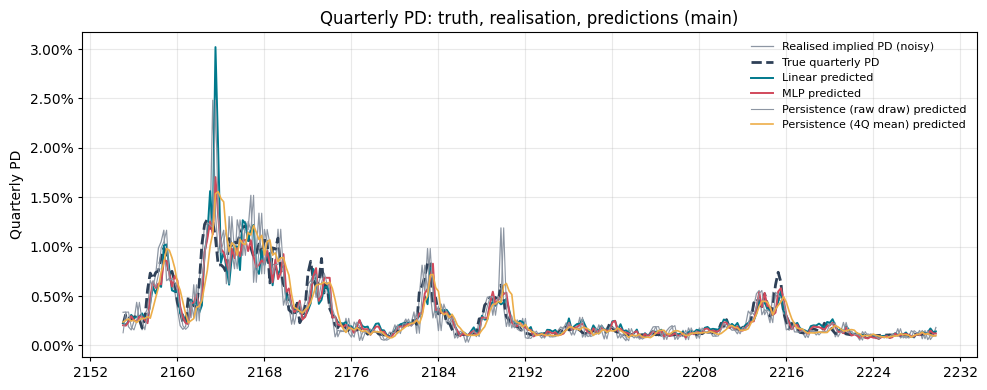

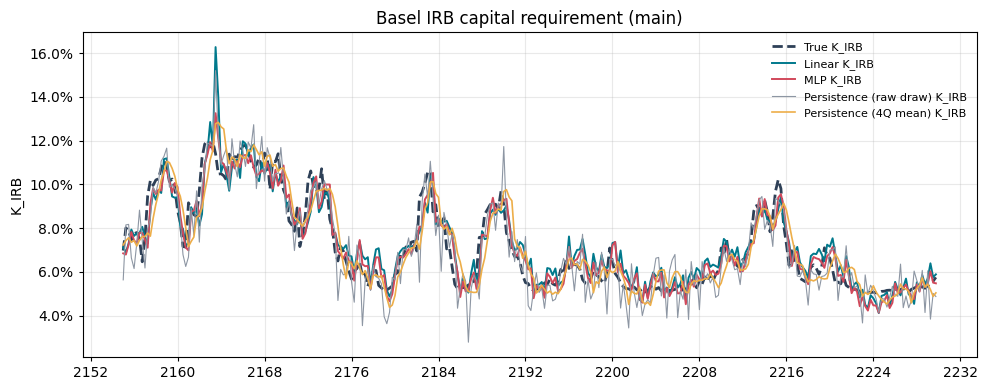

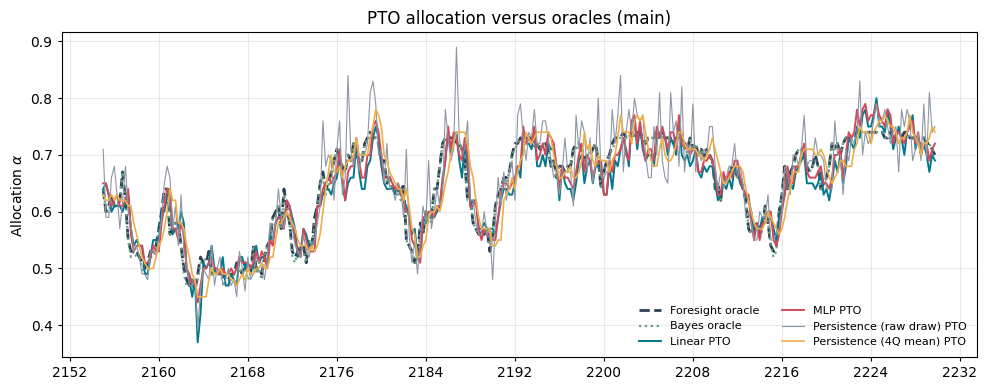

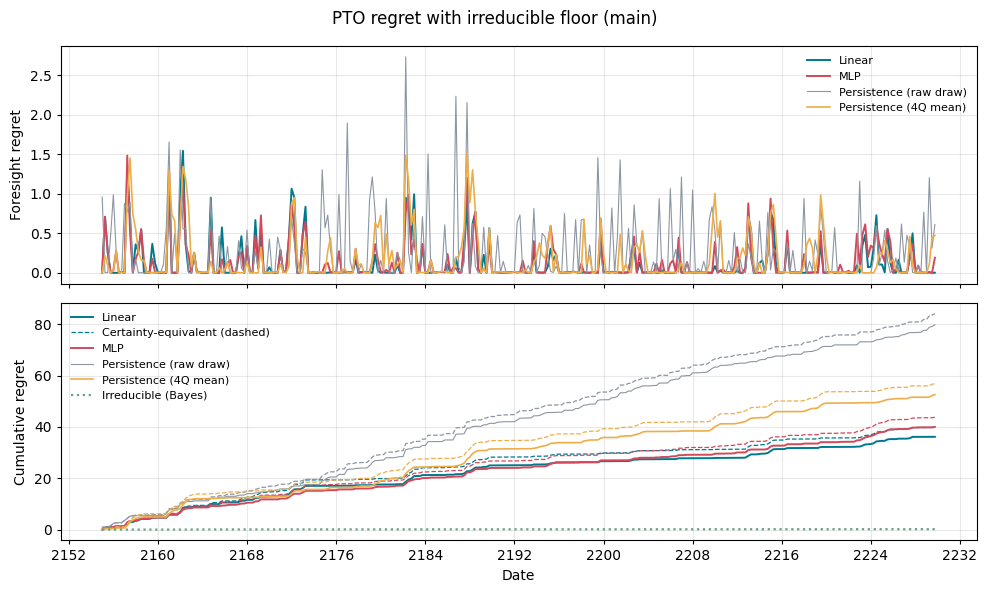

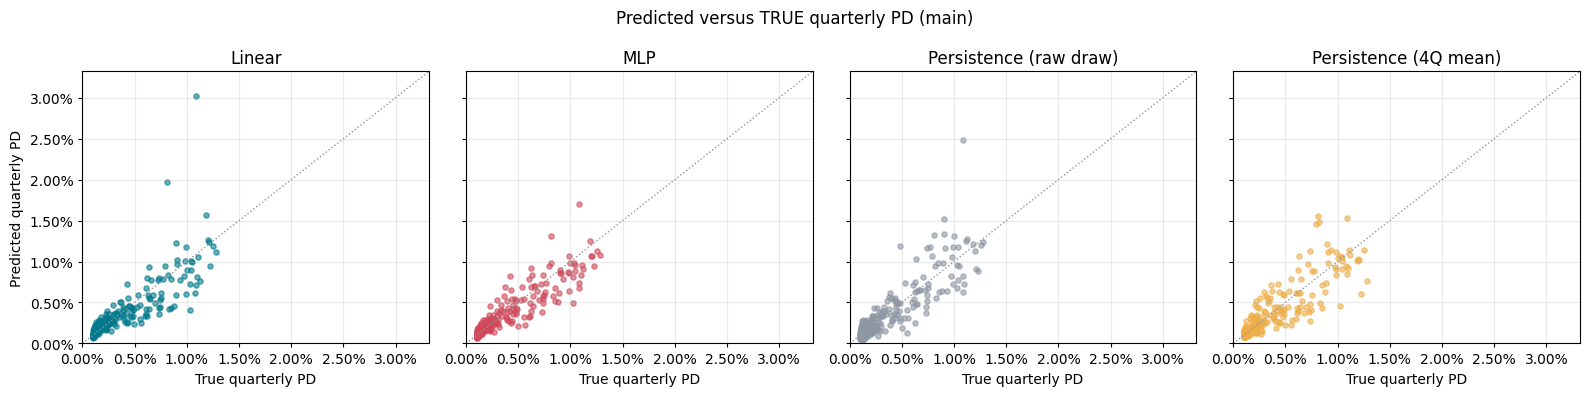

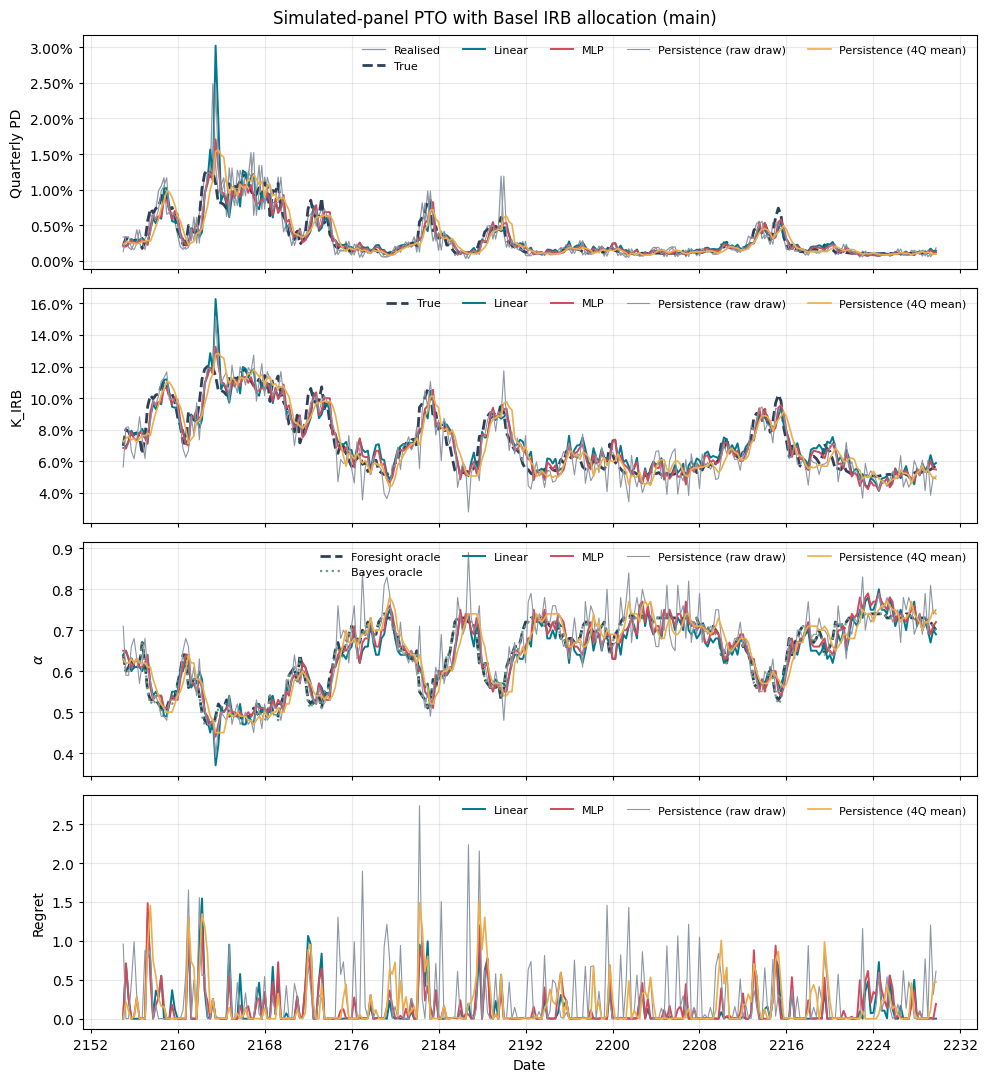

In [33]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"linear": MINOU_COLORS["teal"], "mlp": MINOU_COLORS["coral"], "persistence": MINOU_COLORS["grey"], "persistence_ma4": MINOU_COLORS["gold"]}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "persistence": 0.8, "persistence_ma4": 1.2}
MODEL_LABELS = {"linear": "Linear", "mlp": "MLP", "persistence": "Persistence (raw draw)",
                "persistence_ma4": "Persistence (4Q mean)"}
ORACLE_COLOR = MINOU_COLORS["navy"]
BAYES_COLOR = MINOU_COLORS["sage"]
TRUE_COLOR = MINOU_COLORS["navy"]
REALISED_COLOR = MINOU_COLORS["grey"]

# Which models appear in the static figures. Raw persistence is hidden by default -
# its Vasicek noise clouds every panel; add "persistence" back to include it, or use
# the interactive dial below the figures.
PLOT_MODELS = ["linear", "mlp", "persistence", "persistence_ma4"]

def format_date_axis(ax, plot_df):
    years = plot_df["date"].dt.year
    step = max(2, int(np.ceil((years.max() - years.min()) / 10)))
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()

    # 1. Quarterly PD: truth, noisy realisation, predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised implied PD (noisy)")
    ax.plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True quarterly PD")
    _model_lines(ax, plot_df, "pd_q_hat", " predicted")
    ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD: truth, realisation, predictions ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. K_IRB: true vs model-implied
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True K_IRB")
    _model_lines(ax, plot_df, "k_irb_hat", " K_IRB")
    ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
    plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Allocations: foresight oracle, Bayes oracle, models
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    ax.plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(ax, plot_df, "alpha_hat", " PTO")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"PTO allocation versus oracles ({split_name})")
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. Regret and cumulative regret, with the irreducible floor
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for i, m in enumerate(PLOT_MODELS):
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_ce_{m}"].cumsum(), color=MODEL_COLORS[m], lw=0.9, ls="--",
                     label="Certainty-equivalent (dashed)" if i == 0 else "_nolegend_")
    axes[1].plot(plot_df["date"], plot_df["regret_irreducible"].cumsum(), color=BAYES_COLOR, lw=1.6, ls=":",
                 label="Irreducible (Bayes)")
    axes[0].set_ylabel("Foresight regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, plot_df)
    fig.suptitle(f"PTO regret with irreducible floor ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Predicted vs TRUE PD scatter
    fig, axes = plt.subplots(1, len(PLOT_MODELS), figsize=(4 * len(PLOT_MODELS), 4), sharex=True, sharey=True)
    lims = [0.0, max(plot_df["pd_q_true"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in PLOT_MODELS)) * 1.1]
    for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS):
        ax.scatter(plot_df["pd_q_true"], plot_df[f"pd_q_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
        ax.plot(lims, lims, color=MINOU_COLORS["grey"], lw=1, ls=":")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("True quarterly PD")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
    fig.suptitle(f"Predicted versus TRUE quarterly PD ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_true_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Compact 4-panel thesis figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised")
    axes[0].plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[0], plot_df, "pd_q_hat")
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[1], plot_df, "k_irb_hat")
    axes[1].set_ylabel("K_IRB"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    axes[2].plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, plot_df); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=5)
    fig.suptitle(f"Simulated-panel PTO with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "pto_sim_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)

## Learning curves

Averaged across refits within each split; the MLP curve is the first ensemble seed only.
Windows train for different numbers of epochs (early stopping), so each window's curve is
padded past its stopping point by carrying its last value forward - otherwise the mean
changes composition as windows drop out and produces spurious jumps and staircases.
Note the RMSE level in the top panel is dominated by the Vasicek noise floor of the
realised validation targets, not by calibration error; the loss panel is the early-
stopping criterion (NLL can be negative - the log-variance term - which is normal).

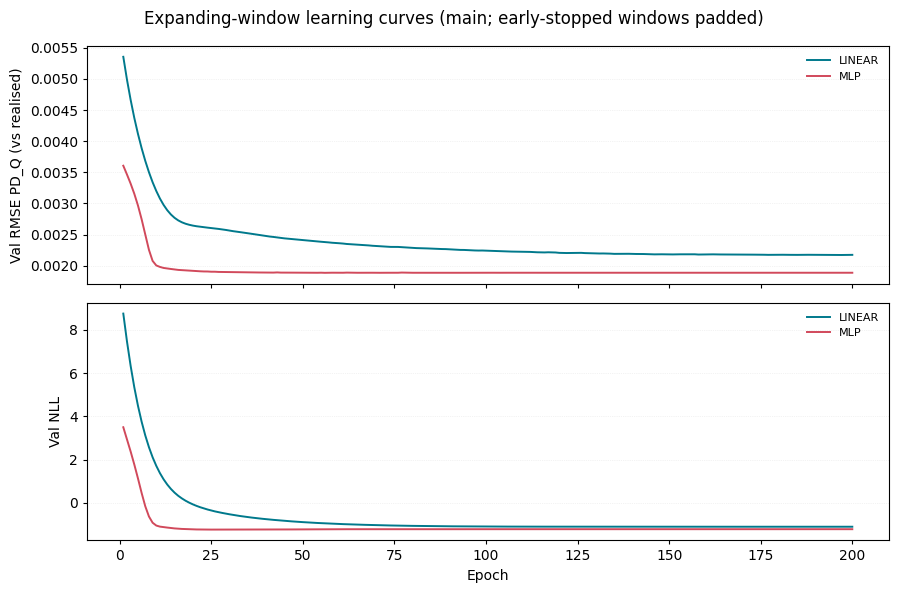

In [34]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        max_epoch = int(split_hist["epoch"].max())
        epoch_idx = pd.RangeIndex(1, max_epoch + 1, name="epoch")
        fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
        for model_name, g_model in split_hist.groupby("model"):
            # Constant composition: pad each window's curve past its early-stopping point
            # by carrying the last value forward before averaging across windows.
            padded = [g.sort_values("epoch").set_index("epoch")[["val_rmse_pd_q", "val_loss"]]
                      .reindex(epoch_idx).ffill()
                      for _, g in g_model.groupby("test_date")]
            mean_curve = pd.concat(padded).groupby(level=0).mean()
            color = MODEL_COLORS.get(model_name, MINOU_COLORS["grey"])
            axes[0].plot(mean_curve.index, mean_curve["val_rmse_pd_q"], color=color, lw=1.4, label=model_name.upper())
            axes[1].plot(mean_curve.index, mean_curve["val_loss"], color=color, lw=1.4, label=model_name.upper())
        axes[0].set_ylabel("Val RMSE PD_Q (vs realised)")
        axes[1].set_ylabel("Val NLL" if LOSS == "nll_vasicek" else f"Val MSE ({TARGET_TRANSFORM} space)")
        axes[1].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name}; early-stopped windows padded)")
        plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()